# Functions for later use

In [8]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def load_epoch_metrics(root_dir) -> pd.DataFrame:
    """
    Scan `root_dir` recursively for files named like:
        metrics_mean_epoch_<N>.csv
        metrics_std_epoch_<N>.csv

    Each CSV must have exactly 2 columns:
        - col 0: metric name (string)
        - col 1: value (numeric)

    For each epoch N, the function:
        - reads the corresponding mean and std files
        - appends "_mean" or "_std" to each metric name
        - constructs one row per epoch with all metrics

    Returns
    -------
    pd.DataFrame
        Index: epoch (int)
        Columns: <metric>_mean, <metric>_std, ...
    """
    root = Path(root_dir)

    # Regex to extract kind ("mean" or "std") and epoch number from filename
    pattern = re.compile(r"metrics_(mean|std)_epoch_(\d+)\.csv$")

    # Nested dict: epoch -> { column_name: value, ... }
    epoch_data = {}

    for csv_path in root.rglob("metrics_*_epoch_*.csv"):
        match = pattern.search(csv_path.name)
        if not match:
            continue  # skip non-matching files that just happen to look similar

        kind, epoch_str = match.groups()
        epoch = int(epoch_str)

        # Read file: two columns (metric, value)
        df = pd.read_csv(csv_path, header=0, names=["metric", "value"])

        # Initialize dict for this epoch if needed
        if epoch not in epoch_data:
            epoch_data[epoch] = {}

        # For each metric, create column `<metric>_<kind>`
        suffix = "_mean" if kind == "mean" else "_std"
        for _, row in df.iterrows():
            metric_name = str(row["metric"])
            col_name = f"{metric_name}{suffix}"
            epoch_data[epoch][col_name] = row["value"]

    # Convert dict-of-dicts into DataFrame
    rows = []
    for epoch, metrics in epoch_data.items():
        row = {"epoch": epoch}
        row.update(metrics)
        rows.append(row)

    if not rows:
        # No matching files -> return empty DataFrame with just an epoch index
        return pd.DataFrame(columns=[])

    result = pd.DataFrame(rows)
    result = result.sort_values("epoch")
    return result

def plot_all_metrics_with_std(df, title="Metrics per Epoch (mean ± std)", subtitle=""):
    """
    Plot MAE, MSE, PSNR, SSIM in a 2×2 grid.
    For each metric, draw:
        - mean line (<metric>_mean)
        - std band (mean ± std)

    The DataFrame must contain columns:
        epoch,
        MAE_mean, MAE_std,
        MSE_mean, MSE_std,
        PSNR_mean, PSNR_std,
        SSIM_mean, SSIM_std.
    """

    metrics = ["MAE", "MSE", "PSNR", "SSIM"]

    # Validate columns
    for m in metrics:
        if f"{m}_mean" not in df.columns or f"{m}_std" not in df.columns:
            raise ValueError(f"DataFrame must contain '{m}_mean' and '{m}_std'")

    # Sort to ensure correct order
    df_sorted = df.sort_values("epoch")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

    for ax, metric in zip(axes.flatten(), metrics):
        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"

        epochs = df_sorted["epoch"].values
        means = df_sorted[mean_col].values
        stds = df_sorted[std_col].values

        ax.plot(epochs, means, label=f"{metric} mean")
        ax.fill_between(
            epochs,
            means - stds,
            means + stds,
            alpha=0.3,
            label=f"{metric} ± std",
        )

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Value")
        ax.grid(True)
        ax.legend()

    # Main title
    fig.suptitle(title, fontsize=18, y=0.98)

    # Subtitle
    fig.text(0.5, 0.94, subtitle, ha="center", fontsize=11)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

def parse_options_file(path):
    """
    Parse an options text file of the form:

        key: value [default: something]

    Returns a dict mapping option names to parsed Python values.
    """
    opts = {}
    pattern = re.compile(r"^\s*([A-Za-z0-9_]+)\s*:\s*(.*?)\s*(?:\[default:.*)?$")

    def convert(value):
        v = value.strip()
        # Handle booleans
        if v.lower() in ("true", "false"):
            return v.lower() == "true"
        # Handle numbers and inf
        if v.lower() == "inf":
            return float("inf")
        # Try int
        try:
            return int(v)
        except ValueError:
            pass
        # Try float
        try:
            return float(v)
        except ValueError:
            pass
        # Return raw string
        return v

    with open(path, "r") as f:
        for line in f:
            m = pattern.match(line)
            if m:
                key, val = m.group(1), m.group(2)
                opts[key] = convert(val)

    return opts

def load_df_and_region(name):
    """
    Load the epoch metrics DataFrame and derive a human-readable region name
    for a given experiment 'name'.
    """
    valid_logs_dir = f"/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/100results/{name}/val_epoch_metrics/"
    opt_path = f"/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/8checkpoints/{name}/val_opt.txt"

    df = load_epoch_metrics(valid_logs_dir)
    opts = parse_options_file(opt_path)

    region = opts['dataroot'].split('/')[-3]
    if region.startswith("6materialized"):
        region = "Full Body"

    return df, region, opts


def plot_from_name(name):
    df, region, opts = load_df_and_region(name)

    plot_all_metrics_with_std(
        df,
        title="Validation Performance",
        subtitle=f"{opts['model']} on {region}, n={opts['num_test']} slices"
    )


def plot_all_regions_mean(names, title="Validation Performance (mean only)", max_epoch=None, plot_name=False):
    """
    For the given list of experiment names, plot the mean curves of
    all regions together in a single 2×2 grid (MAE, MSE, PSNR, SSIM).
    Each subplot: one metric, all regions as separate lines.
    """
    metrics = ["MAE", "MSE", "PSNR", "SSIM"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

    # For each experiment/region, plot its mean line on each metric subplot
    for name in names:
        df, region, opts = load_df_and_region(name)
        df_sorted = df.sort_values("epoch")

        if max_epoch:
            df_sorted = df_sorted[df_sorted["epoch"]<=max_epoch]

        epochs = df_sorted["epoch"].values

        for ax, metric in zip(axes.flatten(), metrics):
            mean_col = f"{metric}_mean"
            if mean_col not in df_sorted.columns:
                continue  # skip if this metric is missing

            means = df_sorted[mean_col].values
            if not plot_name:
                ax.plot(epochs, means, label=region)  # different color per region (matplotlib color cycle)
            else:
                ax.plot(epochs, means, label=name)  # different color per region (matplotlib color cycle)

    # Axis labels, titles, legends
    for ax, metric in zip(axes.flatten(), metrics):
        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Value")
        ax.grid(True)
        ax.legend()

    fig.suptitle(title, fontsize=18, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# Validation: Pix2Pix

## Overview

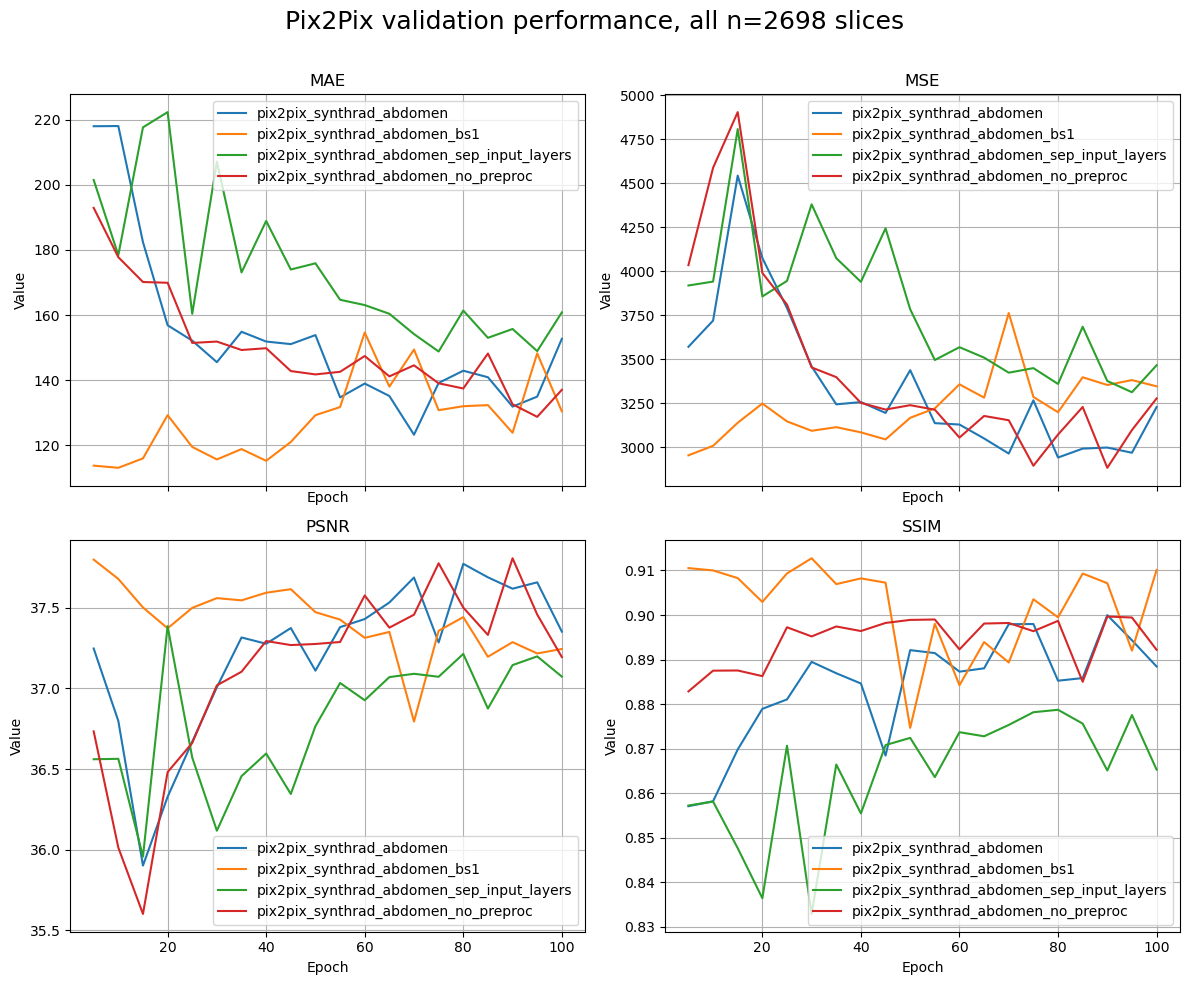

In [14]:
names = ["pix2pix_synthrad_abdomen", "pix2pix_synthrad_abdomen_bs1", "pix2pix_synthrad_abdomen_sep_input_layers", "pix2pix_synthrad_abdomen_no_preproc"]
plot_all_regions_mean(names, "Pix2Pix validation performance, all n=2698 slices", max_epoch=100, plot_name=True)

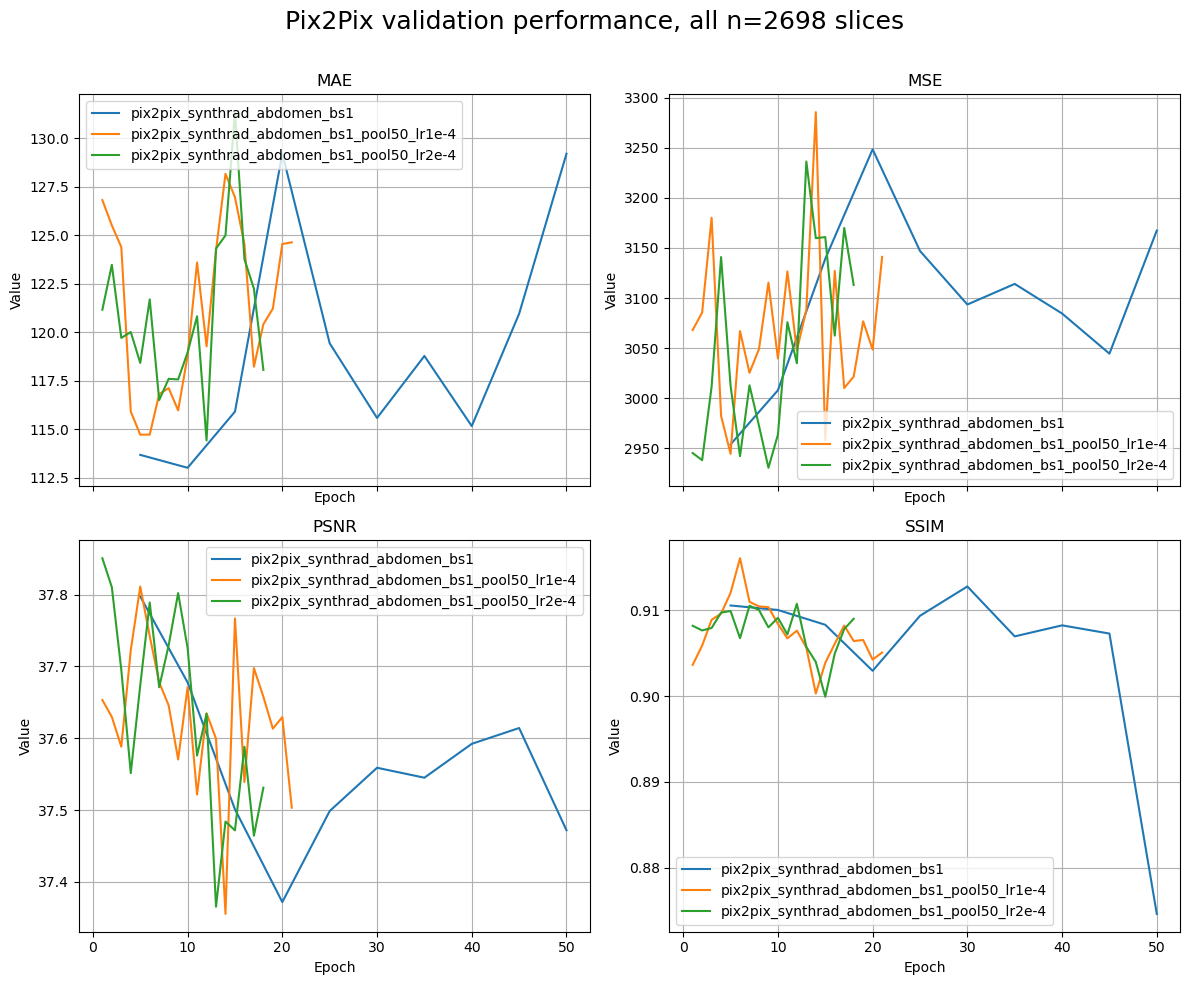

In [15]:
names = ["pix2pix_synthrad_abdomen_bs1", "pix2pix_synthrad_abdomen_bs1_pool50_lr1e-4", "pix2pix_synthrad_abdomen_bs1_pool50_lr2e-4"]
plot_all_regions_mean(names, "Pix2Pix validation performance, all n=2698 slices", max_epoch=50, plot_name=True)

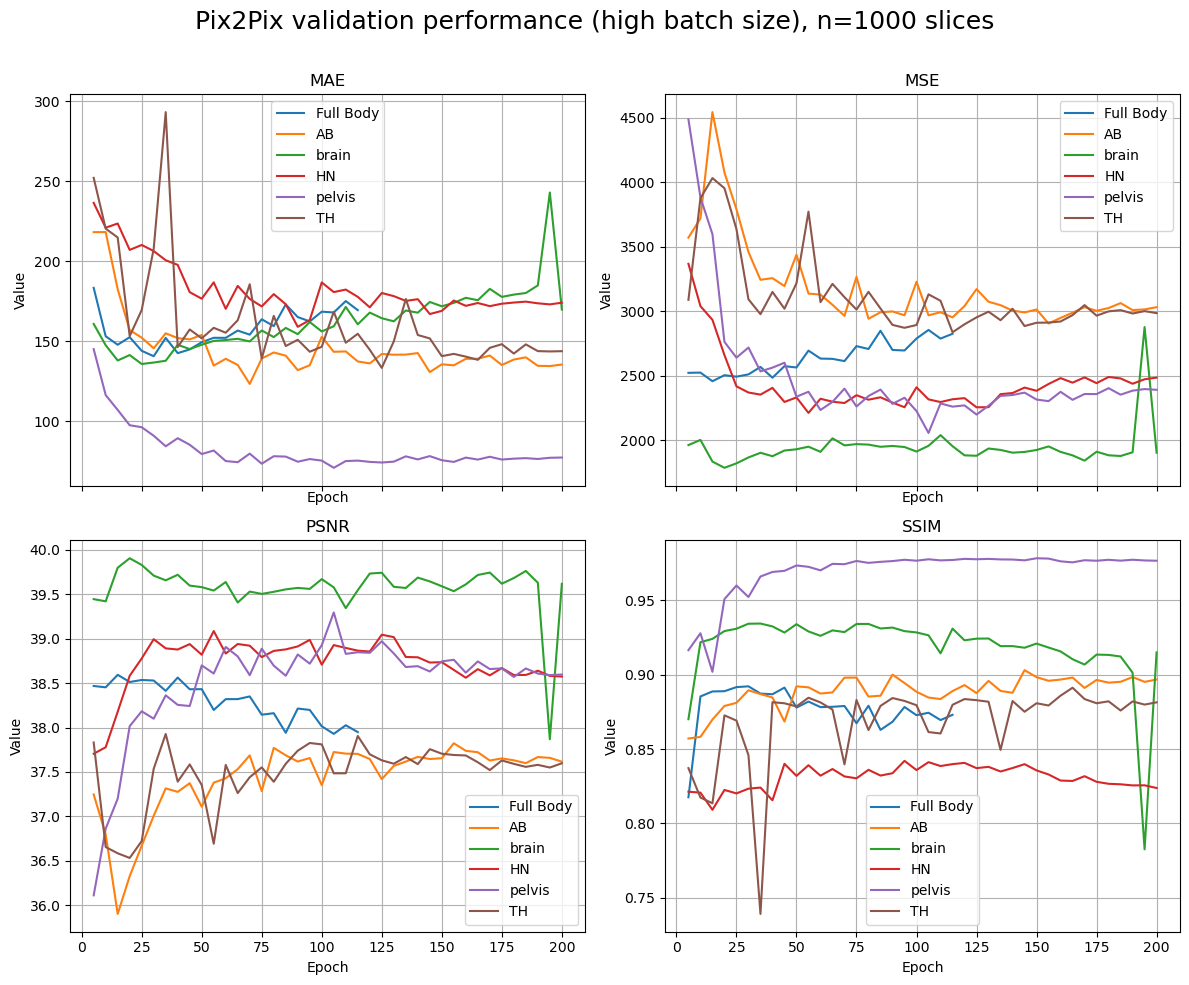

In [8]:
names = ["pix2pix_synthrad_allregions", "pix2pix_synthrad_abdomen", "pix2pix_synthrad_brain", "pix2pix_synthrad_head_neck", "pix2pix_synthrad_pelvis", "pix2pix_synthrad_thorax"]
plot_all_regions_mean(names, "Pix2Pix validation performance (high batch size), n=1000 slices")

## Details

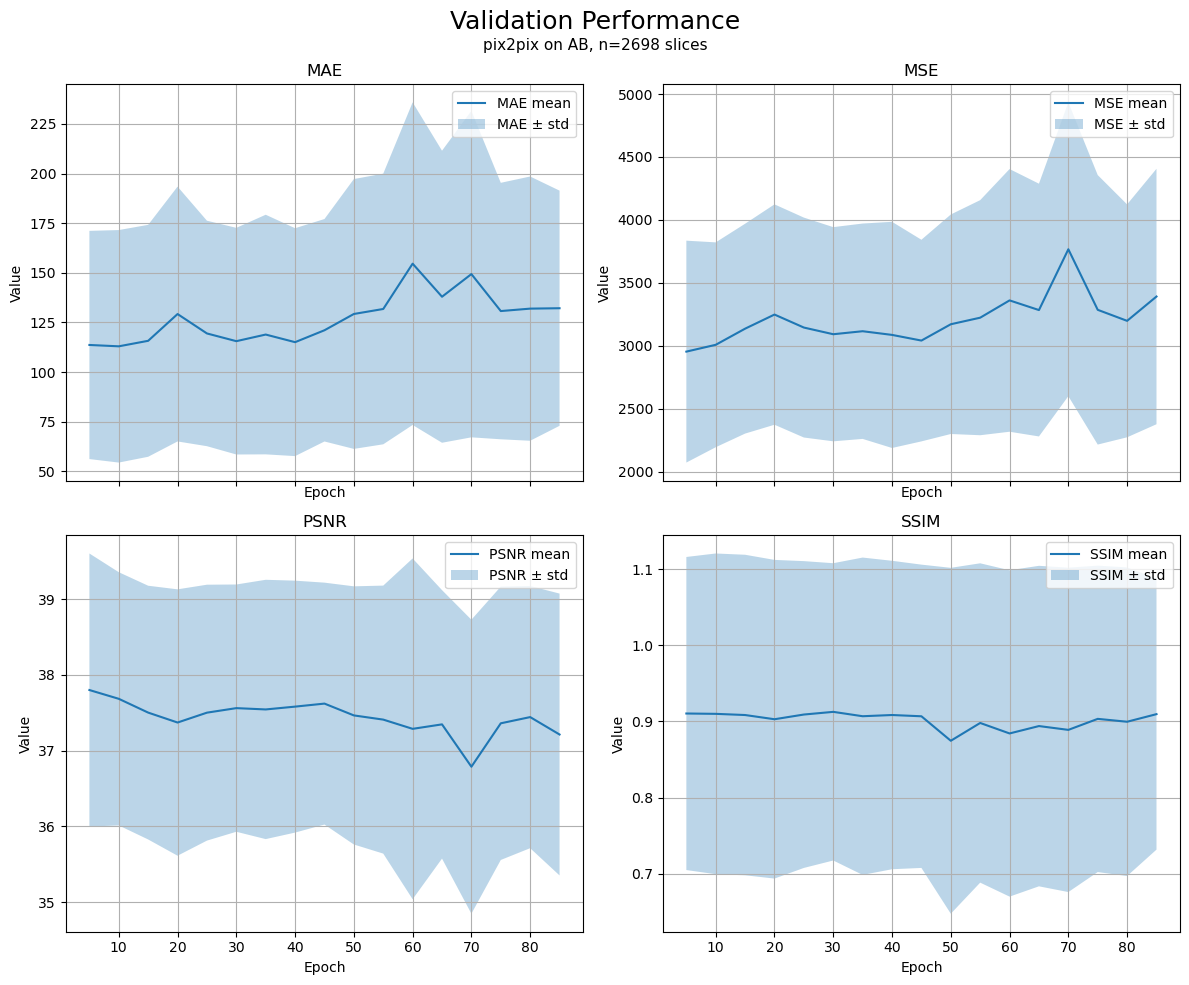

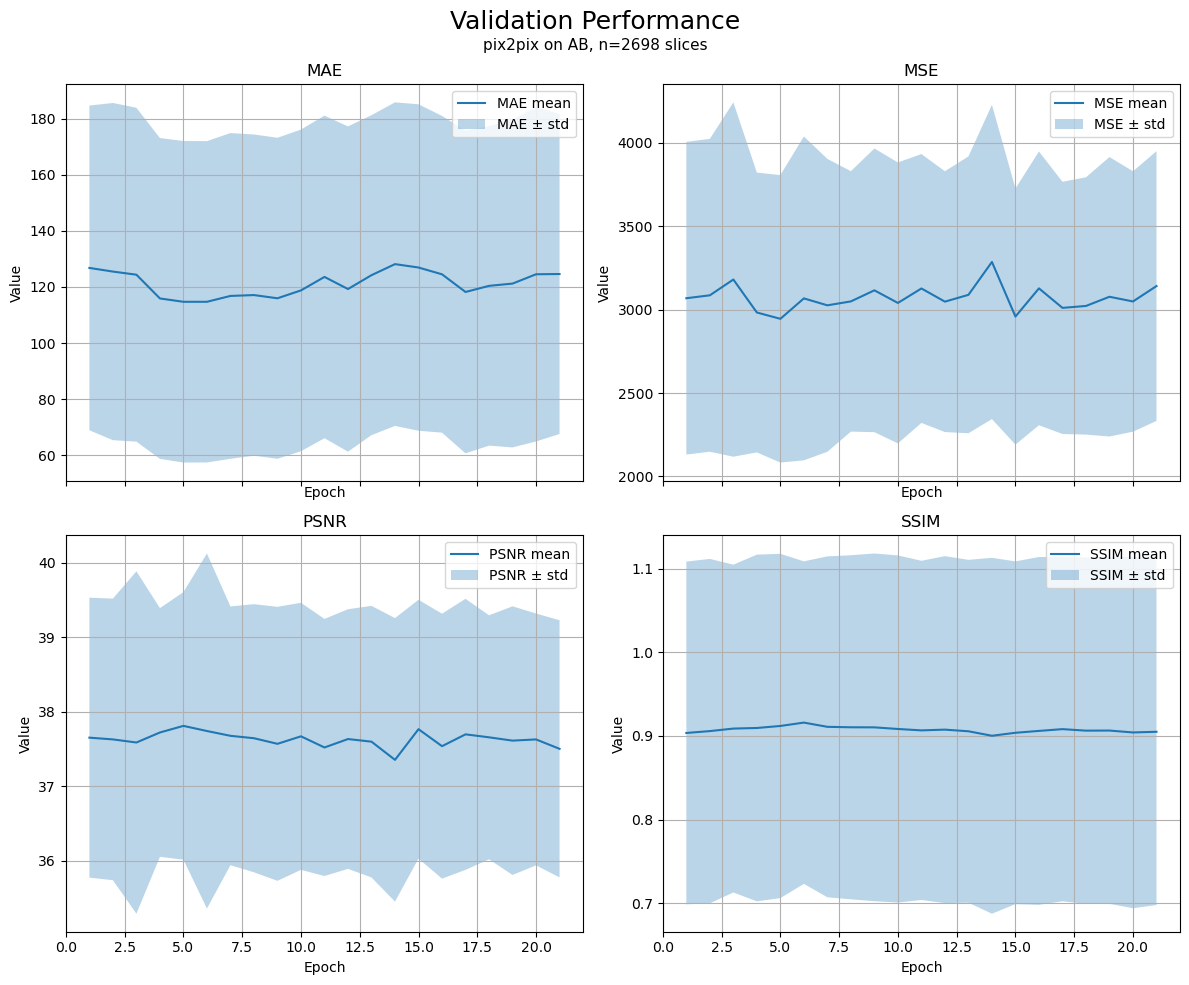

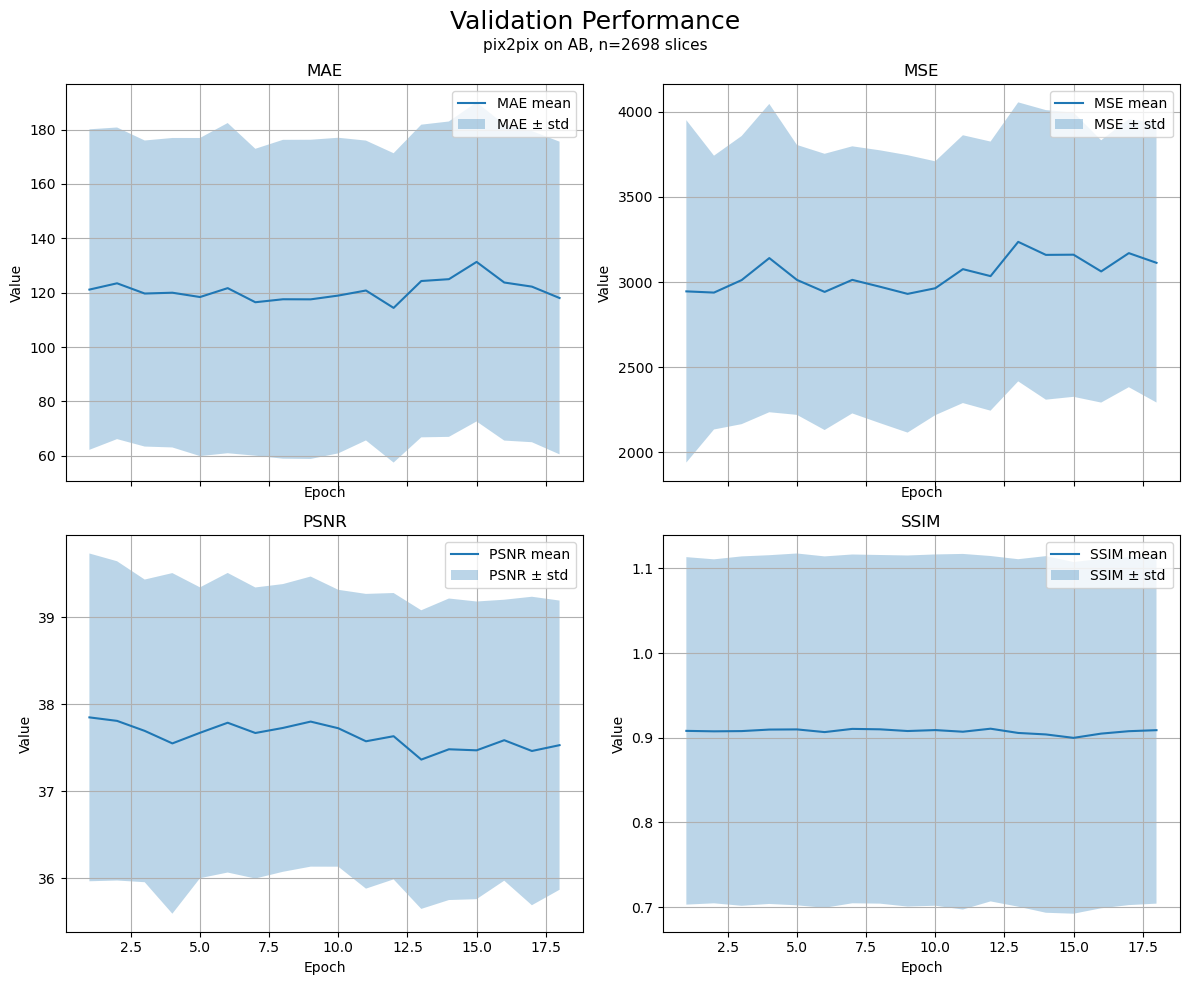

In [13]:
for name in names:
    plot_from_name(name)

# Validation: CycleGAN

## Overview

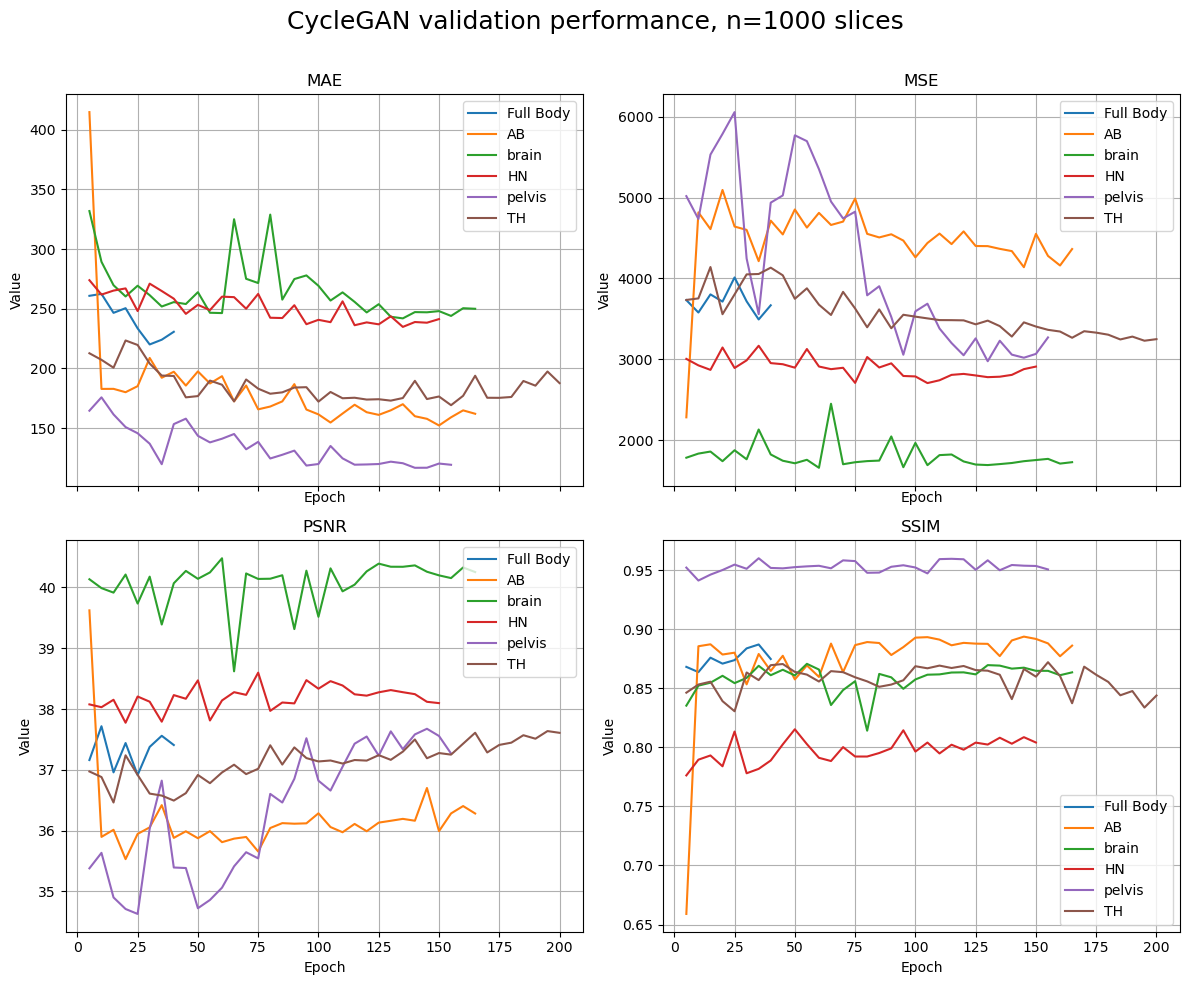

In [4]:
names = ["cyclegan_allregions", "cyclegan_abdomen", "cyclegan_brain", "cyclegan_head_neck", "cyclegan_pelvis", "cyclegan_thorax"]
plot_all_regions_mean(names, "CycleGAN validation performance, n=1000 slices")

## Details

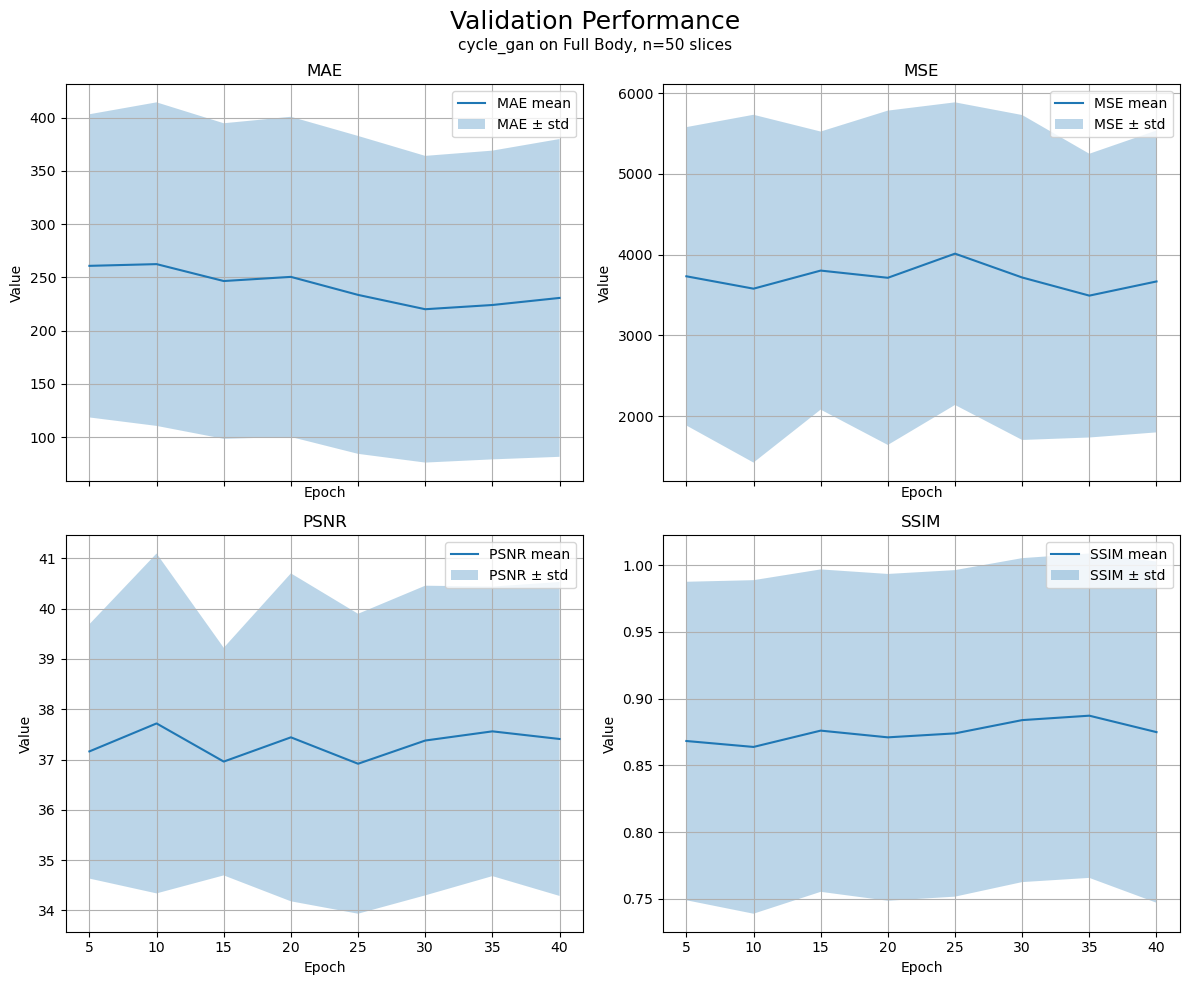

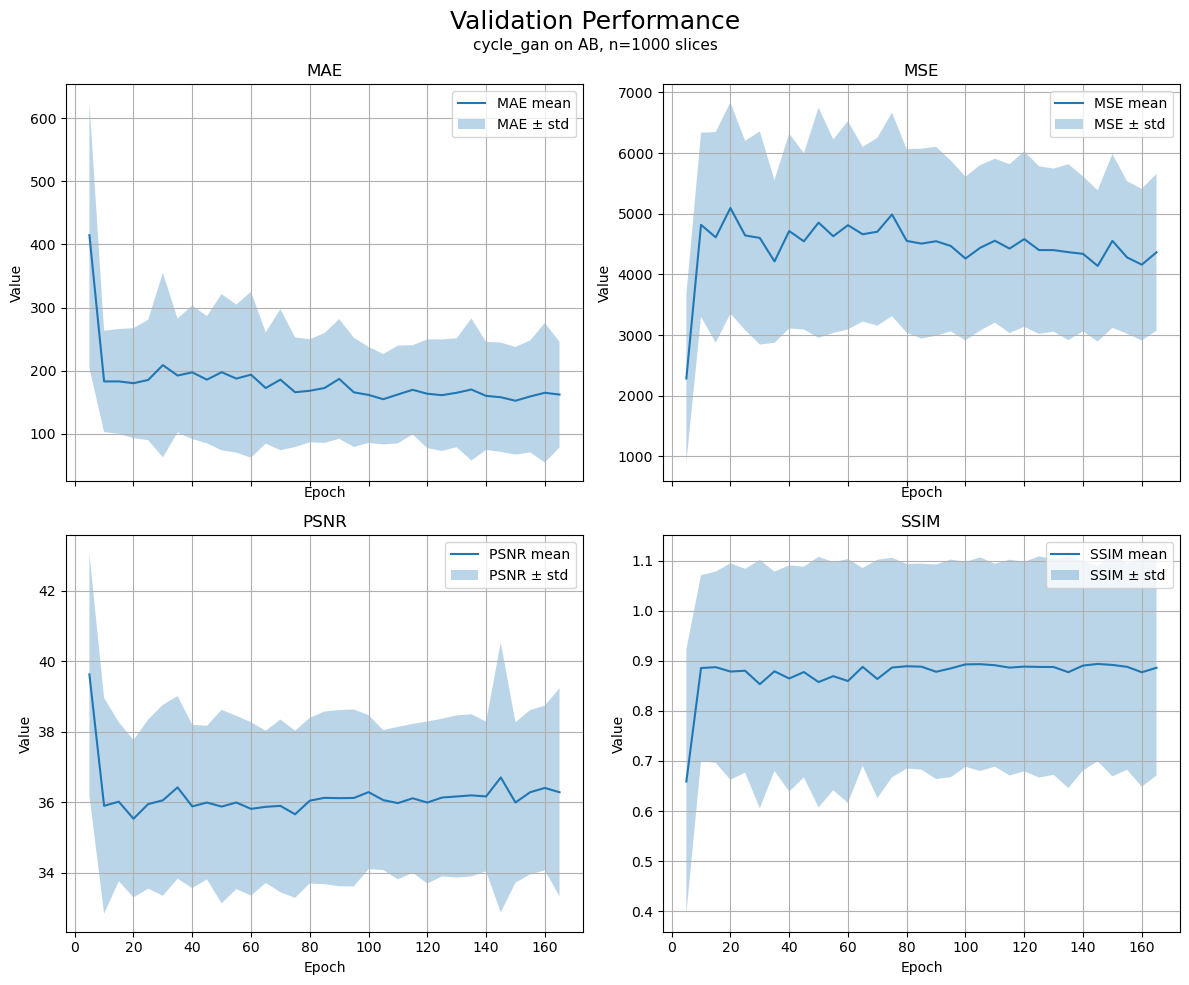

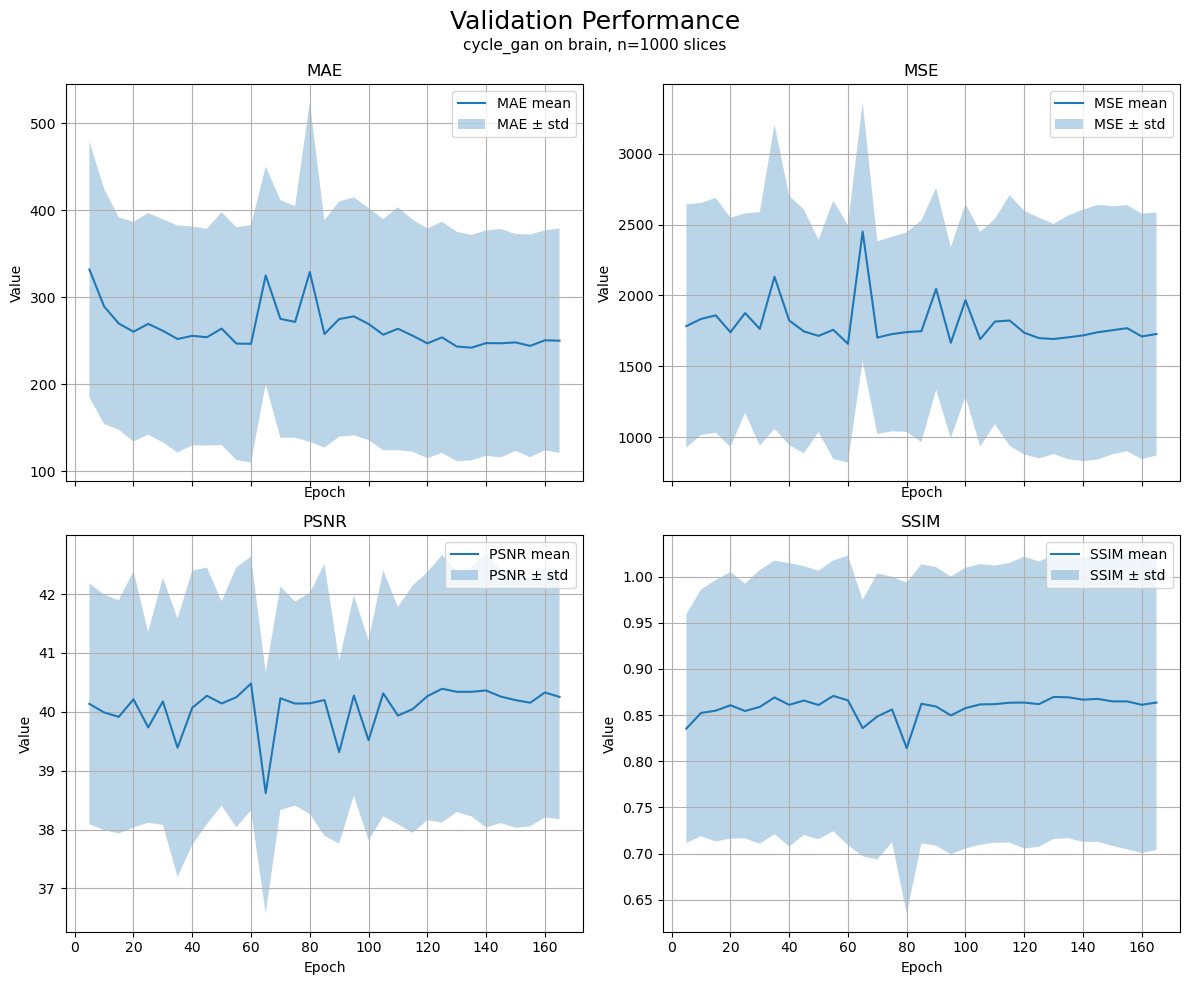

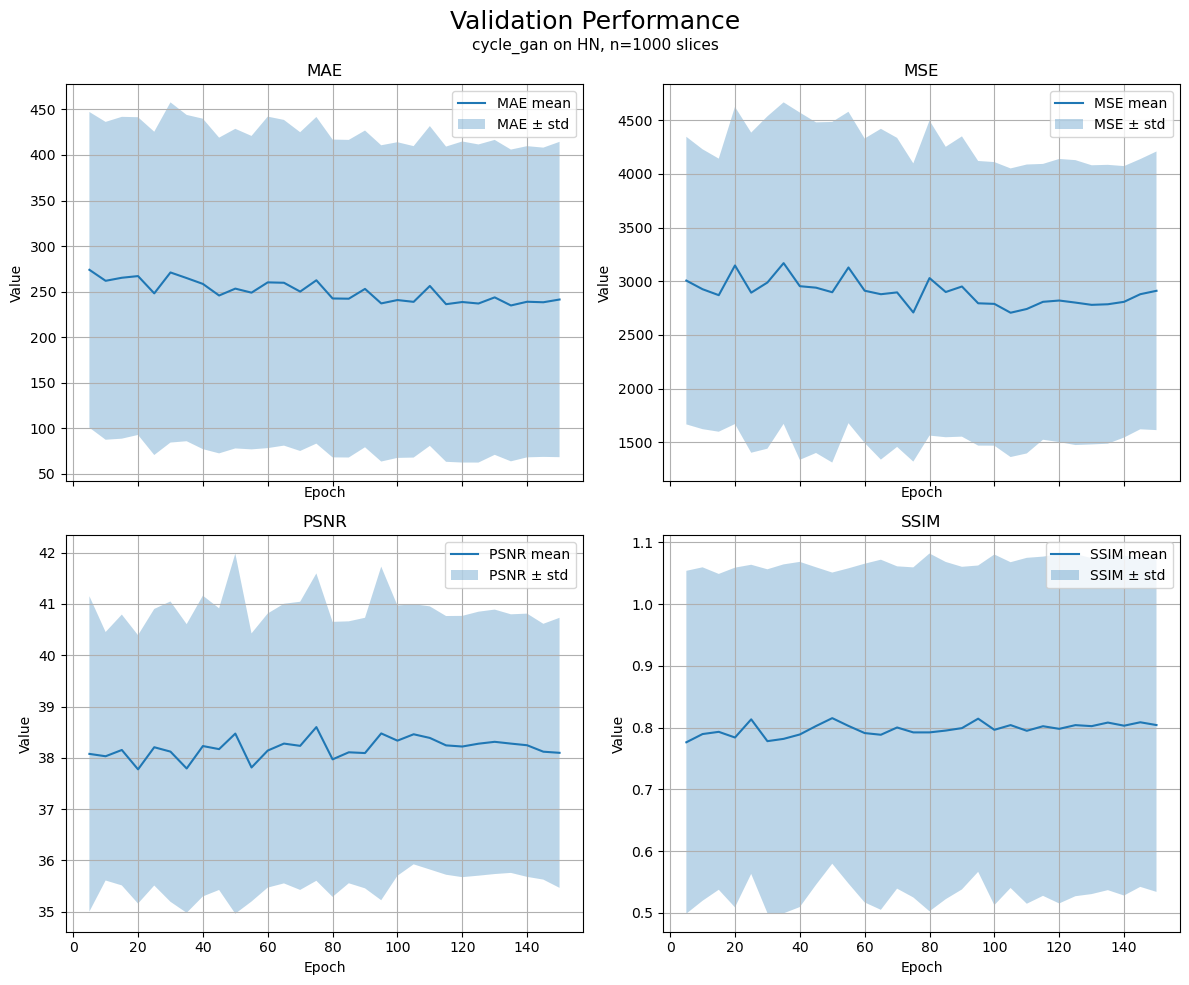

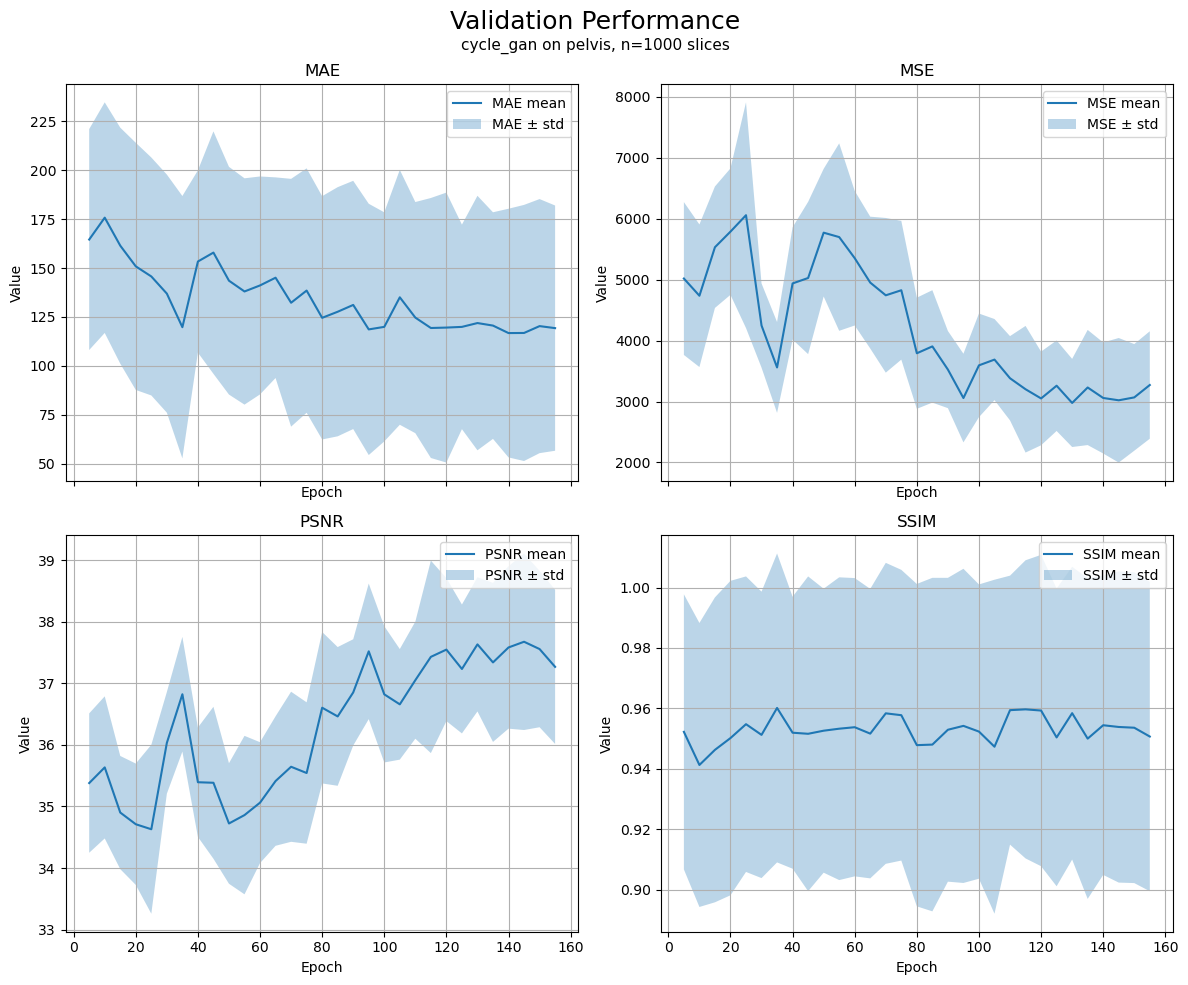

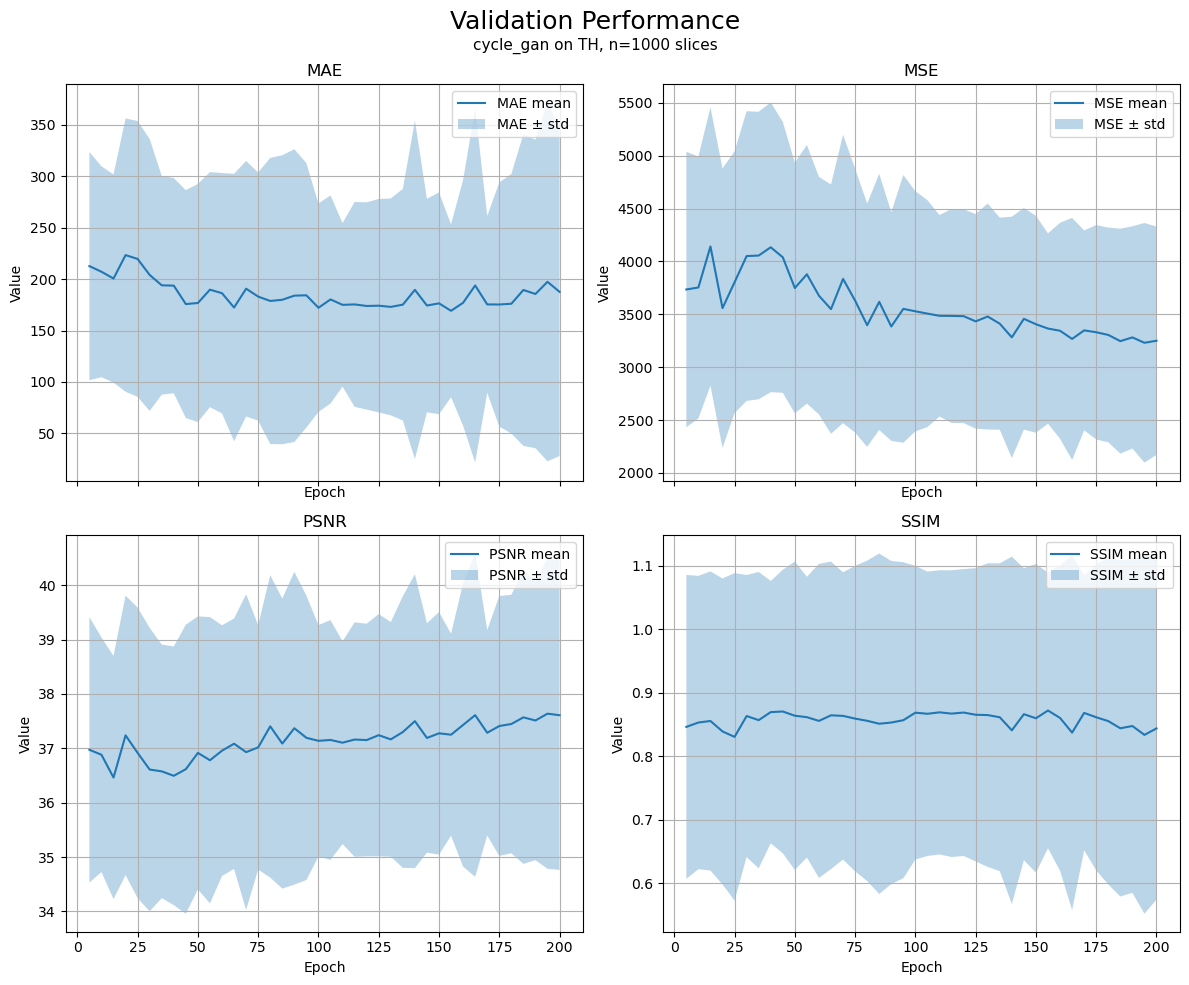

In [5]:
for name in names:
    plot_from_name(name)